# Visualizing the autograd graph of the bigram net

The `loss` tensor secretly holds the **entire** computation graph, the same way a micrograd `Value` held `._prev`. This notebook shows three ways to see it:

1. **`torchviz.make_dot`** — the direct equivalent of Karpathy's `draw_dot` (boxes + ovals via graphviz).
2. **`show_saved=True`** — reveals the *saved forward values* backward will reuse (this is exactly why mutating a tensor mid-graph corrupts grads).
3. **A tiny stdlib walk of `.grad_fn`** — no dependencies, prints the chain.

Plus a bonus demo: watch the buggy update turn `weights` from a leaf into a non-leaf.

In [1]:
import torch
import torch.nn.functional as F
from torchviz import make_dot

## 1. Build the data (same as your bigram notebook)

In [2]:
names = open('names.txt', 'r').read().splitlines()
names = ['.' + i + '.' for i in names]

biagrams = []
for i in names:
    for j in range(len(i) - 1):
        biagrams.append(i[j] + i[j + 1])

stoi = []
for i in names:
    for j in i:
        if j not in stoi:
            stoi.append(j)
rstoi = {}
for num, i in enumerate(sorted(set(stoi))):
    rstoi[i] = num

inp, out = [], []
for i in biagrams:
    inp.append(rstoi[i[0]])
    out.append(rstoi[i[1]])

out = torch.tensor(out)
len(inp)

228146

## 2. Forward pass → loss (vectorized)

Note: the graph's *shape* does not depend on how many bigrams you feed — it's one node per **operation**, not per datum. So this is a small, clean graph even though there are ~228k rows.

In [3]:
g = torch.Generator().manual_seed(2147483647)
onehot = F.one_hot(torch.tensor(inp), num_classes=27).to(torch.float32)
weights = torch.randn(27, 27, generator=g, requires_grad=True)

logits = onehot @ weights
exp = torch.exp(logits)
denom = exp.sum(1, keepdim=True)
probs = exp / denom
target_probs = probs[torch.arange(len(probs)), out]
nulls = torch.log(target_probs) * -1
loss = nulls.mean()
loss

tensor(3.7590, grad_fn=<MeanBackward0>)

## 3. Method 1 — `make_dot`: the `draw_dot` equivalent

How to read it:
- **Blue** node = the tensor you passed in `params` — your **leaf** `weights`. This is the `AccumulateGrad` sink.
- **Gray rectangles** = the backward op of each forward step (`MmBackward`, `ExpBackward`, `LogBackward`, ...). Arrows point the way gradients flow: from `loss` back to `weights`.
- The single node at the bottom with no outgoing arrows is where the gradient lands: `weights.grad`.

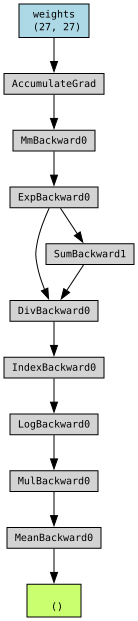

In [4]:
make_dot(loss, params={'weights': weights})

## 4. `show_saved=True` — the values backward will reuse

This is the visual answer to "why does mutating a value corrupt grads?" Each op **saves** the specific forward tensors its derivative needs (e.g. `exp` saves its own output; `mul`/`matmul` save their inputs). Backward reads these saved values — it does **not** recompute from the current `.data`. Change a saved tensor in place and the gradient is computed from the wrong number.

The extra teal nodes below are those saved tensors, hanging off the op that saved them.

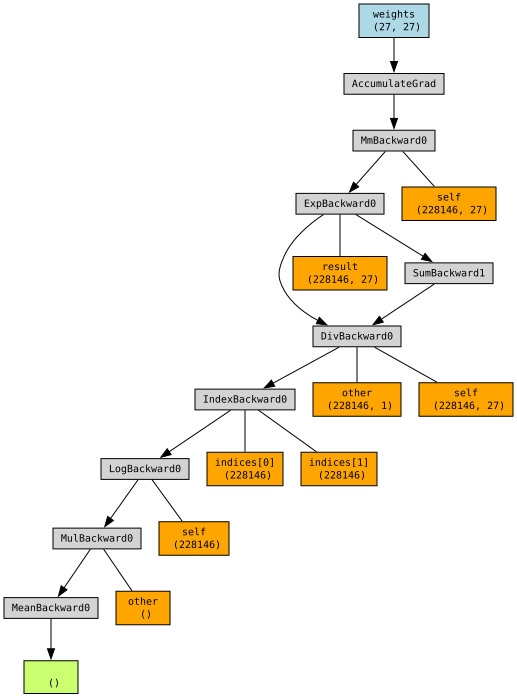

In [5]:
make_dot(loss, params={'weights': weights}, show_saved=True)

## 5. Method 2 — no dependencies: walk `.grad_fn` yourself

`loss.grad_fn` is the last op; `.next_functions` are its inputs — the PyTorch counterpart of micrograd's `._prev`. `AccumulateGrad` at the bottom is your leaf `weights`.

In [6]:
print('loss.grad_fn :', loss.grad_fn)
print()

seen = set()
def walk(fn, depth=0):
    if fn is None or fn in seen:
        return
    seen.add(fn)
    print('  ' * depth + '- ' + type(fn).__name__)
    for nxt, _ in getattr(fn, 'next_functions', ()):
        walk(nxt, depth + 1)

walk(loss.grad_fn)

loss.grad_fn : <MeanBackward0 object at 0x10dda9120>

- MeanBackward0
  - MulBackward0
    - LogBackward0
      - IndexBackward0
        - DivBackward0
          - ExpBackward0
            - MmBackward0
              - AccumulateGrad
          - SumBackward1


## 6. Bonus — watch the buggy update turn `weights` into a non-leaf

This is the bug from the update loop, made visible. `w = w - lr*g` builds a new node (`SubBackward`) and re-points the name → non-leaf → `.grad` is `None`. The `no_grad` + in-place version keeps the same leaf.

In [7]:
# --- buggy: out-of-place rebind ---
w = torch.randn(3, requires_grad=True)
w.sum().backward()
w_bug = w - 0.01 * w.grad
print('buggy   -> is_leaf:', w_bug.is_leaf, '| grad_fn:', type(w_bug.grad_fn).__name__,
      '| .grad:', w_bug.grad)

# --- correct: no_grad + in-place ---
w2 = torch.randn(3, requires_grad=True)
w2.sum().backward()
with torch.no_grad():
    w2 -= 0.01 * w2.grad
print('no_grad -> is_leaf:', w2.is_leaf, '| grad_fn:', w2.grad_fn,
      '| requires_grad:', w2.requires_grad)

buggy   -> is_leaf: False | grad_fn: SubBackward0 | .grad: None
no_grad -> is_leaf: True | grad_fn: None | requires_grad: True


/var/folders/4p/5jt84mnn40g3z993glpry7h40000gn/T/ipykernel_77214/787357780.py:6: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /Users/runner/work/pytorch/pytorch/build/aten/src/ATen/core/TensorBody.h:493.)
  '| .grad:', w_bug.grad)
